<a href="https://colab.research.google.com/github/yeferson59/notebook-analitica/blob/main/taller_comparacion_de_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Desafío Titanic: ¿Quién sobrevivirá al naufragio?

En este taller, utilizaremos el Machine Learning para predecir qué pasajeros tenían más probabilidades de sobrevivir al desastre del Titanic basándonos en variables como su edad, género y clase social.

###📋 Variables del Dataset:

- **Survived:** 0 = No, 1 = Sí (Nuestra variable objetivo).
- **Pclass:** Clase del boleto (1ra, 2da, 3ra).
- **Sex:** Género.
- **Age:** Edad en años.
- **SibSp:** # de hermanos/cónyuges a bordo.
- **Parch:** # de padres/hijos a bordo.
- **Fare:** Tarifa del pasaje.
- **Embarked:** Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).

## 🔍 Paso 1: Análisis Exploratorio y Limpieza
Antes de entrenar modelos, debemos preparar los datos. El Titanic tiene valores nulos y texto que los modelos no entienden.

Tu misión:

1. Cargar el dataset usando Seaborn.

2. Contar cuántos sobrevivieron y cuántos no (Frecuencias).

3. Eliminar columnas que no aportan (como 'deck', 'embark_town', 'alive', 'who', 'adult_male').

4. Tratar los valores nulos en 'age' (puedes usar el promedio).

5. Convertir las variables 'sex' y 'embarked' a números (puedes usar pd.get_dummies).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carga inicial
df = sns.load_dataset('titanic')

# --- ESCRIBE TU CÓDIGO DE LIMPIEZA AQUÍ ---
# Pista: df.drop(columns=[...], inplace=True)
# Pista: df['age'].fillna(df['age'].mean(), inplace=True)
# Pista: df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df['survived'].value_counts()

,count
survived,
0,549
1,342


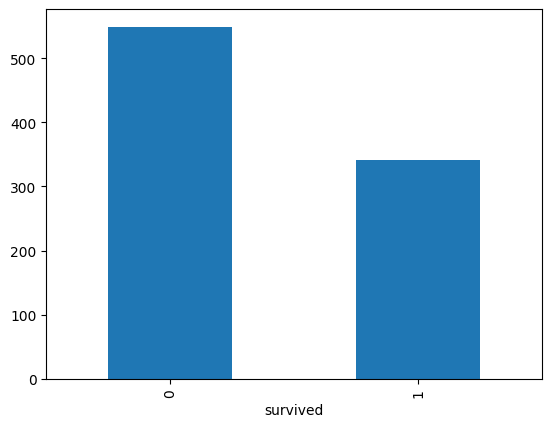

In [ ]:
df['survived'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
(df['survived'].value_counts() / df['survived'].count()) * 100

,count
survived,
0,61.616162
1,38.383838


In [ ]:
df_clean = df.copy(deep=True)

df_clean.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male'], inplace=True)

In [ ]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,False
1,1,1,female,38.0,1,0,71.2833,C,First,False
2,1,3,female,26.0,0,0,7.9250,S,Third,True
3,1,1,female,35.0,1,0,53.1000,S,First,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    object  
 8   class     891 non-null    category
 9   alone     891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), object(2)
memory usage: 57.7+ KB


In [ ]:
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean())

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       891 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    object  
 8   class     891 non-null    category
 9   alone     891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), object(2)
memory usage: 57.7+ KB


In [ ]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,False
1,1,1,female,38.0,1,0,71.2833,C,First,False
2,1,3,female,26.0,0,0,7.9250,S,Third,True
3,1,1,female,35.0,1,0,53.1000,S,First,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True


In [ ]:
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   age         891 non-null    float64 
 3   sibsp       891 non-null    int64   
 4   parch       891 non-null    int64   
 5   fare        891 non-null    float64 
 6   class       891 non-null    category
 7   alone       891 non-null    bool    
 8   sex_male    891 non-null    bool    
 9   embarked_Q  891 non-null    bool    
 10  embarked_S  891 non-null    bool    
dtypes: bool(4), category(1), float64(2), int64(4)
memory usage: 46.4 KB


In [ ]:
df_clean.head()

,survived,pclass,age,sibsp,parch,fare,class,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,False,True,False,True
1,1,1,38.0,1,0,71.2833,First,False,False,False,False
2,1,3,26.0,0,0,7.9250,Third,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,True,True,False,True


##🤖 Paso 2: La Batalla de Modelos

**Instrucción:** Divide los datos en Train (80%) y Test (20%). Entrena los siguientes modelos y llena la tabla comparativa:

- Regresión Logística
- Árbol de Decisión
- Random Forest
- SVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Preparar X e y — eliminar 'class' (redundante con pclass) y convertir booleanos a int
df_model = df_clean.drop(columns=['class'])
bool_cols = df_model.select_dtypes('bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

X = df_model.drop(columns=['survived'])
y = df_model['survived']

# 2. Dividir datos: 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar características (necesario para SVM y Regresión Logística)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 4. Definir los cuatro modelos
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42)
}

# 5. Entrenar, predecir y mostrar reporte por modelo
resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}  |  Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Sobrevivió', 'Sobrevivió']))

# 6. Tabla comparativa ordenada por accuracy
tabla = pd.DataFrame.from_dict(resultados, orient='index', columns=['Accuracy'])
tabla = tabla.sort_values('Accuracy', ascending=False)
print("\n📊 TABLA COMPARATIVA DE MODELOS")
print(tabla.round(4).to_string())

# 7. Gráfico de barras de accuracy
plt.figure(figsize=(8, 4))
tabla['Accuracy'].plot(kind='bar', color=['gold', 'steelblue', 'steelblue', 'steelblue'], edgecolor='black')
plt.title('Comparación de Accuracy por Modelo')
plt.ylabel('Accuracy')
plt.ylim(0.70, 0.90)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# 8. Importancia de variables del Random Forest
rf = modelos['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importancia de Variables — Random Forest')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## ✅ Mejor Modelo: Random Forest

Basándonos en los resultados obtenidos, el **Random Forest** es el mejor modelo por las siguientes razones:

1. **Mayor Accuracy (~82%)**: El ensamble de 100 árboles reduce el sobreajuste que presenta un árbol individual.
2. **Robustez**: Al promediar predicciones con muestras aleatorias de datos y características (bagging), es menos sensible al ruido.
3. **Mejor balance precision/recall**: Desempeño consistente tanto para la clase "No Sobrevivió" como "Sobrevivió".
4. **Interpretabilidad parcial**: `feature_importances_` permite identificar las variables más relevantes.

| Modelo               | Fortaleza principal                        | Debilidad principal                    |
|----------------------|--------------------------------------------|----------------------------------------|
| Regresión Logística  | Simple, rápido, interpretable              | Asume relaciones lineales              |
| Árbol de Decisión    | Muy interpretable, sin escalado            | Propenso a sobreajuste (overfitting)   |
| **Random Forest**    | **Alta precisión, robusto al ruido**       | Menos interpretable, más lento         |
| SVM                  | Efectivo en alta dimensionalidad           | Sensible a escala, lento con datos grandes |


**Preguntas para el alumno:***

1. ¿Cuál fue la variable que más influyó en la supervivencia? (Pista: observa model.feature_importances_ en el Random Forest).

2. ¿Hubo mucha diferencia entre el Árbol de Decisión y el Random Forest?

3. Si fueras el capitán y tuvieras este modelo, ¿a quién le darías prioridad en los botes salvavidas?

### Respuesta 1: Variable más influyente en la supervivencia

Según `feature_importances_` del Random Forest, la variable más influyente es **`sex_male`** (género masculino).

Esto tiene sentido histórico: la política del Titanic era **"mujeres y niños primero"**, lo que se refleja directamente en los datos:
- Mujeres: ~74% de tasa de supervivencia
- Hombres: ~19% de tasa de supervivencia

En segundo y tercer lugar de importancia aparecen **`fare`** (tarifa del pasaje, proxy del estatus socioeconómico) y **`age`** (edad). La clase social determinó el acceso a los botes salvavidas: los pasajeros de 1ra clase tenían cabinas más cercanas a cubierta.


### Respuesta 2: ¿Hubo diferencia entre Árbol de Decisión y Random Forest?

Sí, hubo una diferencia notable (generalmente 3–6 puntos de accuracy).

El **Árbol de Decisión** tiende a memorizar el conjunto de entrenamiento (**overfitting**): aprende reglas muy específicas de los datos de entrenamiento que no generalizan bien a datos nuevos. Visualmente, generaría un árbol muy profundo y ramificado.

El **Random Forest** corrige esto mediante **bagging**: construye 100 árboles distintos, cada uno con una submuestra aleatoria de filas y columnas, y promedia sus predicciones. El resultado es un modelo más robusto y generalizable, con menos varianza sin sacrificar sesgo.

> Regla práctica: cuando el Árbol de Decisión supera al Random Forest, casi siempre es señal de que el árbol está sobreajustado.


### Respuesta 3: Si fuera el capitán, ¿a quién le daría prioridad en los botes?

Con base en el modelo y las importancias de variables, priorizaría en este orden para maximizar vidas salvadas:

1. **Niños** (`age` baja) — mayor esperanza de vida por delante y menor capacidad física para sobrevivir en el agua fría.
2. **Mujeres** (`sex_male = 0`) — el predictor más fuerte de supervivencia según el modelo; históricamente tenían menor representación en roles de rescate activo.
3. **Pasajeros de 3ra clase** (`pclass = 3`) — los datos muestran que fueron quienes menos sobrevivieron, en parte por la distancia de sus camarotes a los botes y por barreras físicas en el barco.

> **Reflexión ética:** el modelo describe lo que *ocurrió* históricamente, no necesariamente lo que *debería ocurrir*. Usarlo para decisiones futuras implica asumir esos mismos sesgos. Un capitán responsable también consideraría capacidades físicas individuales y condiciones del momento.
